# Phase 5: Exploratory Data Analysis (EDA)

This notebook continues the pipeline from `01_Data_Cleaning.ipynb`. The cleaned dataset
produced there is loaded below, and the `Revenue` feature is recreated so the analysis
in this notebook can run independently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv", parse_dates=["InvoiceDate"])

print("Loaded cleaned dataset:", df.shape)
df.head()

Loaded cleaned dataset: (779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("Dataset Shape :", df.shape)

print("\nUnique Customers :", df["Customer ID"].nunique())

print("Unique Products :", df["StockCode"].nunique())

print("Unique Invoices :", df["Invoice"].nunique())

print("Countries :", df["Country"].nunique())

Dataset Shape : (779425, 8)

Unique Customers : 5878
Unique Products : 4631
Unique Invoices : 36969
Countries : 41


## Business Question 1

### How large is the cleaned dataset?

Before analyzing customer behavior, it is important to understand the overall scale of the business.

The following statistics summarize the number of:

- Transactions
- Customers
- Products
- Invoices
- Countries

These metrics provide an overview of the retail operation.

In [4]:
country_transactions = (
    df.groupby("Country")["Invoice"]
      .count()
      .sort_values(ascending=False)
      .head(10)
)

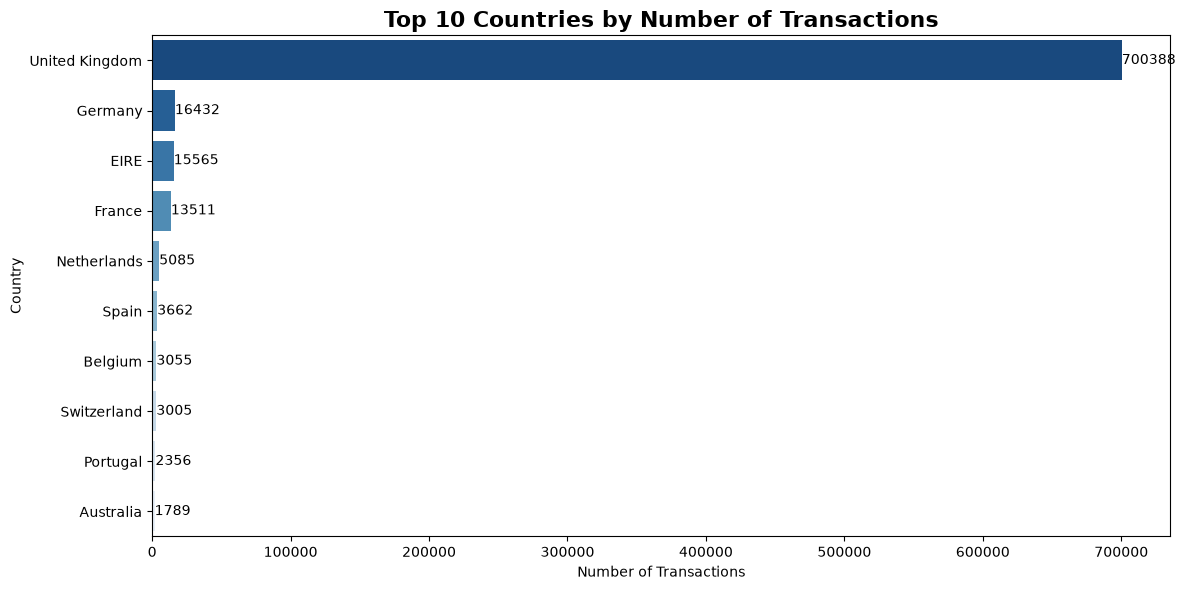

In [5]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=country_transactions.values,
    y=country_transactions.index,
    hue=country_transactions.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Countries by Number of Transactions", fontsize=16, fontweight="bold")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.tight_layout()
plt.show()

In [6]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [7]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

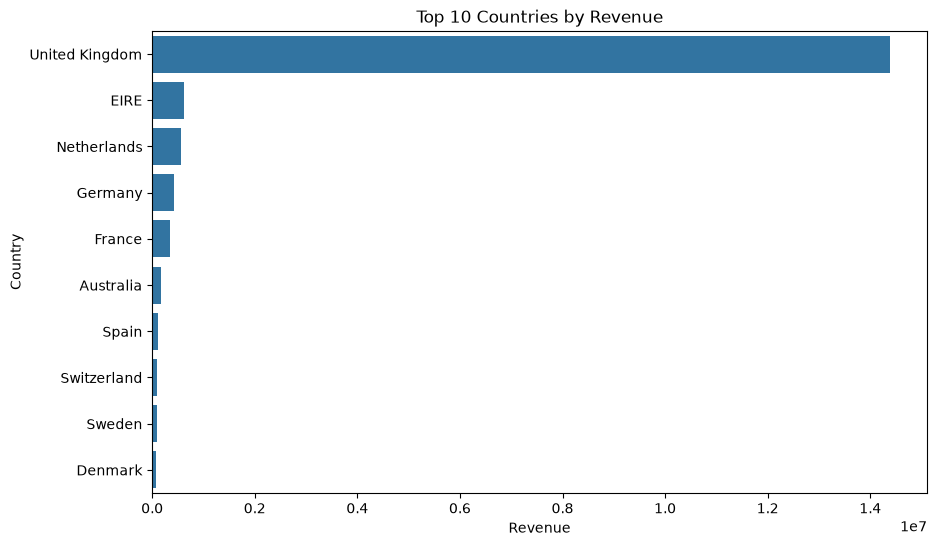

In [8]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue")

plt.ylabel("Country")

plt.show()

In [9]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

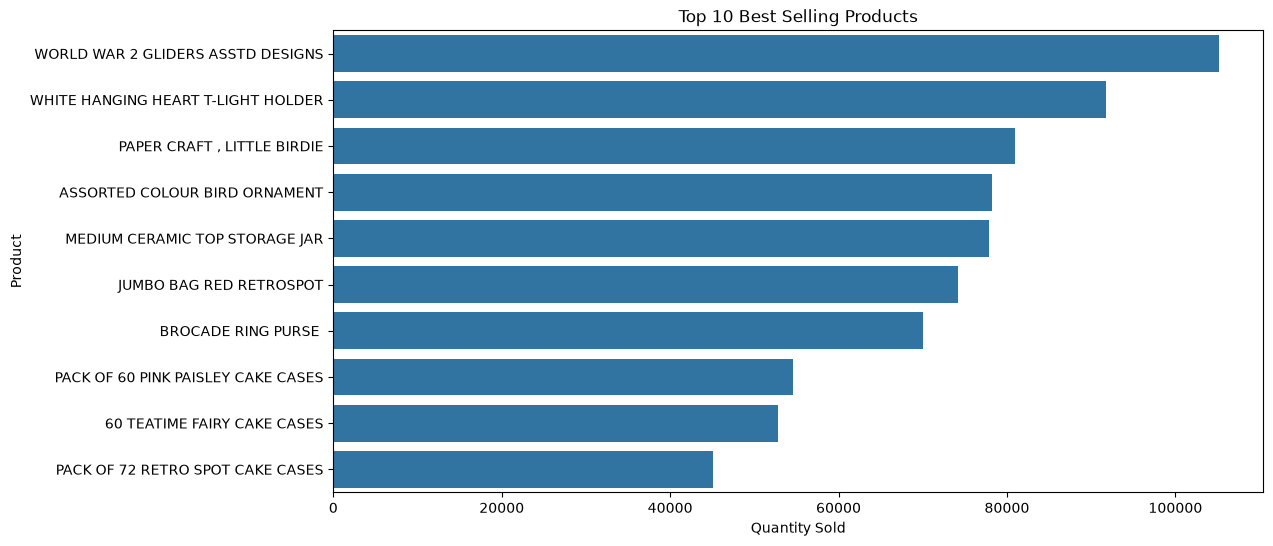

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best Selling Products")

plt.xlabel("Quantity Sold")

plt.ylabel("Product")

plt.show()

### Observation

- The United Kingdom accounts for the overwhelming majority of transactions.
- Germany, France, and EIRE contribute significantly fewer transactions.
- Customer activity is highly concentrated within a single market.

### Business Insight

The business is heavily dependent on the United Kingdom. While international customers are present, expanding customer acquisition and engagement in other countries could reduce geographical concentration risk and increase revenue diversification.

## Business Question 2

### How do sales change over time?

Customer purchasing behavior often varies across different months and seasons.

Analyzing monthly sales trends helps identify seasonal demand, peak shopping periods, and overall business growth.

These insights support inventory planning, marketing campaigns, and sales forecasting.

In [11]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December


In [12]:
monthly_revenue = (
    df.groupby(["Year", "Month"])["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,Year,Month,Revenue
0,2009,12,683504.010
1,2010,1,555802.672
2,2010,2,504558.956
3,2010,3,696978.471
4,2010,4,591982.002


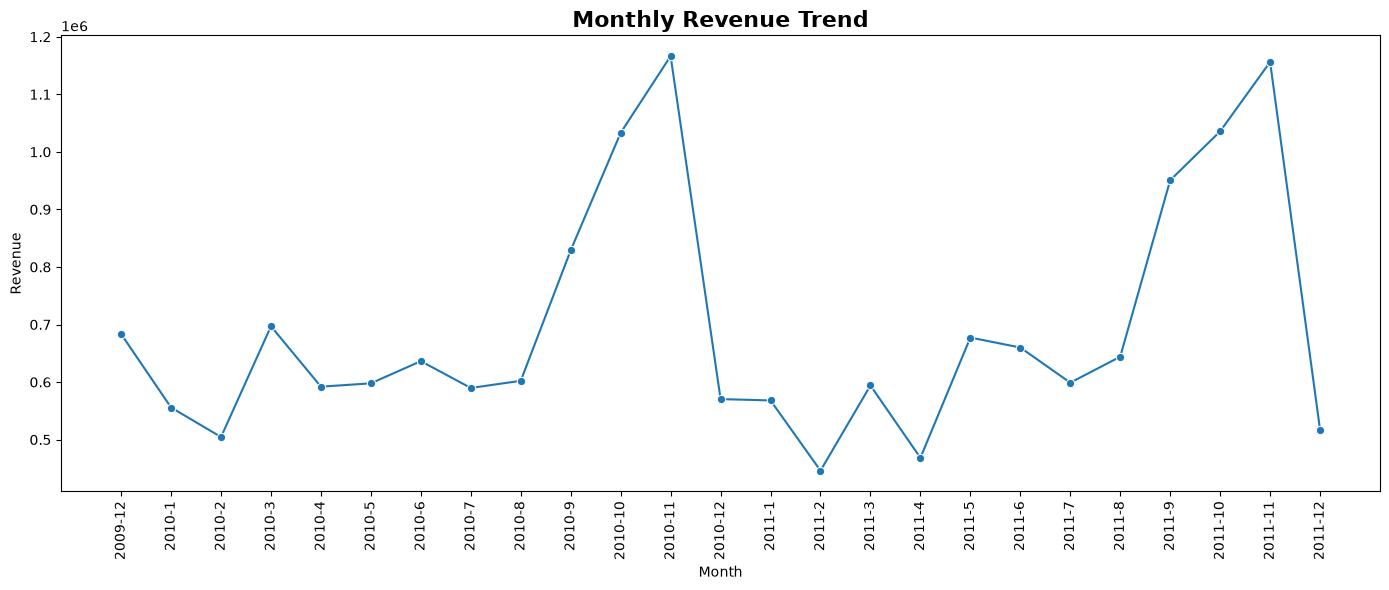

In [13]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_revenue,
    x=range(len(monthly_revenue)),
    y="Revenue",
    marker="o"
)

labels = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str)
)

plt.xticks(range(len(labels)), labels, rotation=90)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Business Question 3

### Who are the highest-value customers?

Revenue is not distributed equally among customers.

Identifying the highest revenue-generating customers helps businesses prioritize customer retention strategies and develop personalized marketing campaigns.

In [14]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

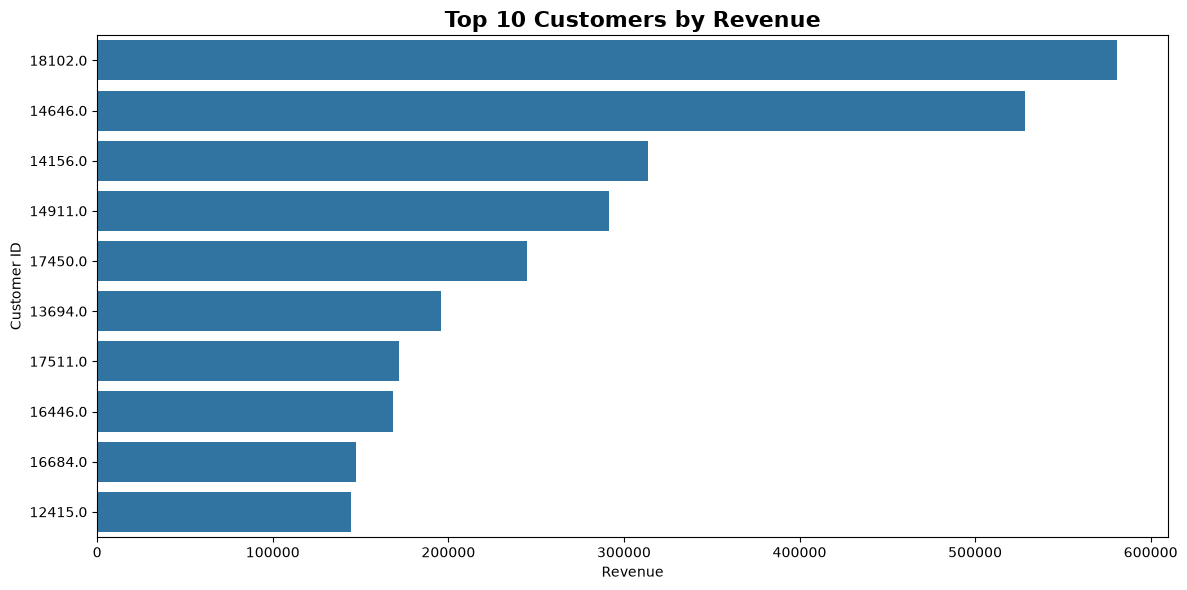

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_revenue.values,
    y=customer_revenue.index.astype(str)
)

plt.title("Top 10 Customers by Revenue", fontsize=16, fontweight="bold")

plt.xlabel("Revenue")

plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

## Business Question 4

### Which customers purchase most frequently?

Purchase frequency is an important indicator of customer loyalty.

Customers who place orders frequently are more likely to become long-term customers and contribute consistently to business revenue.

In [16]:
customer_frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

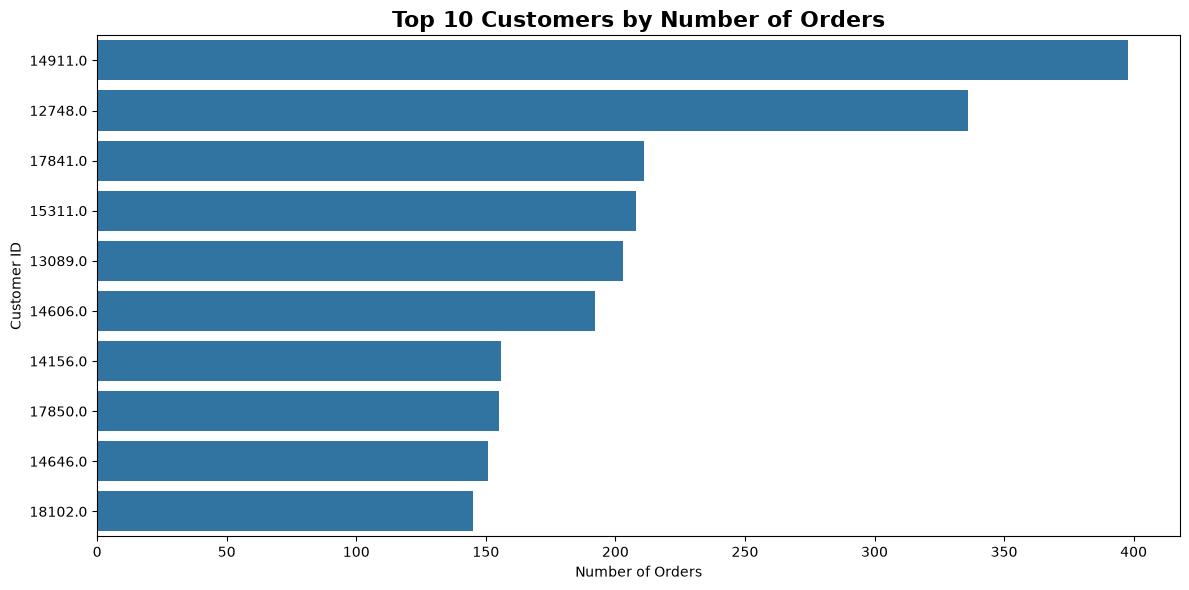

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=customer_frequency.values,
    y=customer_frequency.index.astype(str)
)

plt.title("Top 10 Customers by Number of Orders", fontsize=16, fontweight="bold")

plt.xlabel("Number of Orders")

plt.ylabel("Customer ID")

plt.tight_layout()

plt.show()

## What is the Average Order Value (AOV)?

### A very important business KPI.

In [18]:
invoice_value = (
    df.groupby("Invoice")["Revenue"]
      .sum()
)

In [19]:
average_order_value = invoice_value.mean()

print(f"Average Order Value : £{average_order_value:.2f}")

Average Order Value : £469.98
